Fátima Lastra Incera, Manuel Griseri, Daniel Badaire

# Cost of hedging XVA

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import datetime
import pandas as pd
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True, parents=True)

## 1. Paper results replication

### 1.1. Black-Scholes

In [2]:
# Parameters
N_foreign = 1e9          # Foreign notional (1 billion)
S0 = 0.7                 # FX spot rate (domestic per foreign)
K = S0                   # Strike = spot (ATM forward, zero rates)
sigma = 0.075            # Log-normal FX volatility
T = 5.0                  # Maturity in years

credit_spread = 0.01     # 100 bps
R = 0.4                  # Recovery rate
lam = credit_spread / (1 - R)  # Hazard rate (credit triangle)

# Hedging parameters
Ds_pct = 50_000          # Asset delta threshold: 50,000 dom per 1% S move
spread_pips = 0.0001     # 1 pip friction (spread to mid)

Dc_bp = 5_000            # Credit delta threshold: 5,000 dom per bp
credit_friction_bp = 5   # 5 bps credit friction

# Interest rates all zero => rF = 0, no FVA
rF = 0.0
m_X = 2                  # Marginal HVA multiplier (approx)

In [3]:
# BS utilities (zero interest rates)
def bs_call(S, K, sigma, tau):
    """BS call price with zero rates."""
    if tau <= 1e-12:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_delta(S, K, sigma, tau):
    """BS call delta with zero rates."""
    if tau <= 1e-12:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)

def bs_gamma(S, K, sigma, tau):
    """BS call gamma with zero rates."""
    if tau <= 1e-12:
        return 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return norm.pdf(d1) / (S * sigma * np.sqrt(tau))

In [4]:
print(f"Hazard rate lambda = {lam:.6f}")
print(f"lambda*(1-R) = {lam*(1-R):.4f}")

Hazard rate lambda = 0.016667
lambda*(1-R) = 0.0100


### 1.2. CVA

In [5]:
# CVA calculation (Eq. 16 with rF=0)
# CVA(S, t) = -lambda*(1-R)*N * integral_t^T e^{-lambda*(u-t)} * C(S,K,sigma,u-t) du
def cva_at(S, t, lam=lam, R=R, N=N_foreign, K=K, sigma=sigma, T=T):
    """Compute CVA at spot S, time t."""
    if t >= T:
        return 0.0
    def integrand(tau):
        return np.exp(-lam * tau) * bs_call(S, K, sigma, tau)
    val, _ = quad(integrand, 0, T - t, limit=200)
    return -lam * (1 - R) * N * val

# Verify CVA at inception
cva_0 = cva_at(S0, 0)
print(f"CVA at inception = {cva_0:,.0f}")
print(f"Paper value:       -1,578,792")

CVA at inception = -1,484,293
Paper value:       -1,578,792


In [6]:
# CVA greeks (finite differences)
dS = S0 * 1e-4      # Small bump for S
dlam = lam * 1e-4   # Small bump for lambda

def cva_gamma_ss(S, t):
    """d^2(CVA)/dS^2 at (S, t)."""
    c_up = cva_at(S + dS, t)
    c_dn = cva_at(S - dS, t)
    c_mid = cva_at(S, t)
    return (c_up - 2*c_mid + c_dn) / dS**2

def cva_delta(S, t):
    """d(CVA)/dS at (S, t)."""
    return (cva_at(S + dS, t) - cva_at(S - dS, t)) / (2*dS)

def cva_cross_gamma(S, t):
    """d^2(CVA)/(dS dlambda) at (S, t)."""
    c_pp = cva_at(S + dS, t, lam=lam + dlam)
    c_pm = cva_at(S + dS, t, lam=lam - dlam)
    c_mp = cva_at(S - dS, t, lam=lam + dlam)
    c_mm = cva_at(S - dS, t, lam=lam - dlam)
    return (c_pp - c_pm - c_mp + c_mm) / (4 * dS * dlam)

# Test at inception
gamma_ss_0 = cva_gamma_ss(S0, 0)
cross_gamma_0 = cva_cross_gamma(S0, 0)
print(f"Gamma_ss(S0, 0) = {gamma_ss_0:,.0f}")
print(f"Cross gamma(S0, 0) = {cross_gamma_0:,.0f}")

Gamma_ss(S0, 0) = -330,247,129
Cross gamma(S0, 0) = -1,440,529,389


### 1.3. HVA

In [7]:
# Friction costs and thresholds

# Asset: D_s = 50,000 per percent
# This means: threshold on accumulated delta expressed as
#   PnL per 1% spot move = |delta_foreign| * 0.01 * S = Ds_pct
# => delta_foreign_threshold = Ds_pct / (0.01 * S)
# Cost per rehedge: psi_s = spread * delta_foreign_threshold
#   = 0.0001 * delta_foreign_threshold

def Ds_natural(S):
    """Asset delta threshold in foreign units."""
    return Ds_pct / (0.01 * S)

def psi_s(S):
    """Friction cost of asset rehedge (domestic currency)."""
    return spread_pips * Ds_natural(S)

# Credit: D_c = 5,000 per bp
# CR01 = d(CVA)/d(lambda) * 0.0001 (sensitivity per 1bp)
# D_c = threshold on change in CR01 (in domestic)
# Gamma_sc_bp = d^2(CVA)/(dS dlambda) * 0.0001
# Cost per credit rehedge: the CDS notional for CR01 = D_c is
#   N_cds = D_c / (risky_PV01), risky_PV01 = int e^(-lam*u) du * 0.0001
# psi_c = 5bps * N_cds * risky_annuity * 0.0001 ... simplifies to:
# psi_c = credit_friction_bp * D_c (in units of bps * (dom/bp))

def risky_annuity(t):
    """Risky annuity from t to T."""
    if t >= T:
        return 0.0
    return (1 - np.exp(-lam * (T - t))) / lam

def psi_c():
    """Friction cost of credit rehedge (domestic currency).
    The CDS notional for CR01 = Dc is Nc = Dc / (annuity * 0.0001).
    The cost = 5bps * Nc * annuity * 0.0001 = 5bps * Dc / 0.0001 * 0.0001 = 5 * Dc."""
    return credit_friction_bp * Dc_bp

print(f"D_s natural (foreign) at S0: {Ds_natural(S0):,.0f}")
print(f"psi_s at S0: {psi_s(S0):,.1f} domestic")
print(f"psi_c: {psi_c():,.0f} domestic")
print(f"Risky annuity at t=0: {risky_annuity(0):.4f}")

D_s natural (foreign) at S0: 7,142,857
psi_s at S0: 714.3 domestic
psi_c: 25,000 domestic
Risky annuity at t=0: 4.7973


In [8]:
# HVA calculation via Monte Carlo (Eq. 33)

# H^c_X = -int_0^T E[D_{rF+m*lam}(0,u) * (
#     psi_s/Ds^2 * sigma^2 * S^2 * Gamma_ss^2
#   + psi_c/Dc^2 * sigma^2 * S^2 * Gamma_sc_bp^2
#   + lambda * psi_s(|delta_c|)
# )] du
#
# where:
#   - sigma^2 * S^2 = (sigma_0 * S)^2 (total variance of S)
#   - Gamma_ss = d^2(CVA)/dS^2
#   - Gamma_sc_bp = d^2(CVA)/(dS dlambda) * 0.0001 (cross-gamma in bp units)
#   - delta_c = dV/dS = N_foreign (constant for FX forward)
#   - D_{rF+m*lam}(0,u) = e^{-(rF + m*lam)*u} = e^{-2*lam*u}

np.random.seed(42)

N_paths = 100
N_steps = 50  # Time steps (quarters = 50 per year)
dt = T / N_steps

# Time grid
times = np.linspace(0, T, N_steps + 1)

# Simulate GBM paths for S (risk-neutral with zero rates)
# dS = sigma * S * dW
Z = np.random.randn(N_paths, N_steps)
S_paths = np.zeros((N_paths, N_steps + 1))
S_paths[:, 0] = S0
for i in range(N_steps):
    S_paths[:, i+1] = S_paths[:, i] * np.exp(
        -0.5 * sigma**2 * dt + sigma * np.sqrt(dt) * Z[:, i]
    )

print(f"Simulated {N_paths} paths with {N_steps} steps")
print(f"dt = {dt:.4f} years")

Simulated 100 paths with 50 steps
dt = 0.1000 years


In [9]:
# Compute HVA integrand along each path
# For efficiency, precompute gamma functions analytically

def cva_gamma_ss_analytical(S, t):
    """d^2(CVA)/dS^2 using analytical BS gamma."""
    if t >= T:
        return 0.0
    def integrand(tau):
        return np.exp(-lam * tau) * bs_gamma(S, K, sigma, tau)
    val, _ = quad(integrand, 1e-6, T - t, limit=200)
    return -lam * (1 - R) * N_foreign * val

def cva_cross_gamma_analytical(S, t):
    """d^2(CVA)/(dS dlambda) analytical."""
    if t >= T:
        return 0.0
    def integrand(tau):
        return np.exp(-lam * tau) * (1 - lam * tau) * bs_delta(S, K, sigma, tau)
    val, _ = quad(integrand, 1e-6, T - t, limit=200)
    return -(1 - R) * N_foreign * val

# Arrays to store per-path, per-time integrands
asset_hva_integrand = np.zeros((N_paths, N_steps + 1))
credit_hva_integrand = np.zeros((N_paths, N_steps + 1))
closeout_hva_integrand = np.zeros((N_paths, N_steps + 1))

# Also store gammas for Figure 1
gamma_ss_values = np.zeros((N_paths, N_steps + 1))
cross_gamma_values = np.zeros((N_paths, N_steps + 1))

discount_factor = np.exp(-(rF + m_X * lam) * times)  # e^{-2*lam*t}

for step_idx in range(N_steps + 1):
    t = times[step_idx]
    if step_idx % 50 == 0:
        print(f"  Processing step {step_idx}/{N_steps} (t={t:.2f})")

    for path_idx in range(N_paths):
        S = S_paths[path_idx, step_idx]

        # CVA gamma (asset)
        g_ss = cva_gamma_ss_analytical(S, t)
        gamma_ss_values[path_idx, step_idx] = g_ss

        # CVA cross-gamma (asset vs credit)
        g_sc = cva_cross_gamma_analytical(S, t)
        cross_gamma_values[path_idx, step_idx] = g_sc

        # Cross-gamma in bp units
        g_sc_bp = g_sc * 0.0001

        # Volatility term: sigma_0^2 * S^2
        sig2_S2 = sigma**2 * S**2

        # Asset HVA integrand (Eq. 33, term 1)
        Ds_nat = Ds_natural(S)
        ps = psi_s(S)
        asset_hva_integrand[path_idx, step_idx] = (
            (ps / Ds_nat**2) * sig2_S2 * g_ss**2
        )

        # Credit HVA integrand (Eq. 33, term 2)
        pc = psi_c()
        credit_hva_integrand[path_idx, step_idx] = (
            (pc / Dc_bp**2) * sig2_S2 * g_sc_bp**2
        )

        # Closeout HVA integrand (Eq. 33, term 3)
        delta_c = N_foreign  # dV/dS for FX forward = N_foreign
        closeout_hva_integrand[path_idx, step_idx] = (
            lam * spread_pips * abs(delta_c)
        )

print("Done computing integrands.")

  Processing step 0/50 (t=0.00)
  Processing step 50/50 (t=5.00)
Done computing integrands.


### 1.4. Results

In [10]:
# Numerical integration (trapezoidal rule)
def integrate_paths(integrand_array, discount, dt):
    """Integrate discounted integrand over time for each path, return mean and stderr."""
    # Apply discount factor
    discounted = integrand_array * discount[np.newaxis, :]
    # Trapezoidal integration over time for each path
    path_integrals = np.trapezoid(discounted, dx=dt, axis=1)
    mean_val = np.mean(path_integrals)
    stderr = np.std(path_integrals) / np.sqrt(len(path_integrals))
    return -mean_val, stderr  # Negative sign from HVA formula

asset_hva, asset_err = integrate_paths(asset_hva_integrand, discount_factor, dt)
credit_hva, credit_err = integrate_paths(credit_hva_integrand, discount_factor, dt)
closeout_hva, closeout_err = integrate_paths(closeout_hva_integrand, discount_factor, dt)

total_hva = asset_hva + credit_hva + closeout_hva
total_err = np.sqrt(asset_err**2 + credit_err**2 + closeout_err**2)

print("\n" + "="*60)
print("TABLE 2: Day-zero HVA numbers")
print("="*60)
print(f"{'Quantity':<20} {'Value':>15} {'Error':>10}  {'Paper':>15}")
print("-"*60)
print(f"{'CVA':<20} {cva_0:>15,.0f} {'':>10}  {-1578792:>15,}")
print(f"{'Closeout HVA':<20} {closeout_hva:>15,.0f} {closeout_err:>10,.0f}  {-5783:>15,}")
print(f"{'Asset HVA':<20} {asset_hva:>15,.0f} {asset_err:>10,.0f}  {-3018:>15,}")
print(f"{'Credit HVA':<20} {credit_hva:>15,.0f} {credit_err:>10,.0f}  {-442447:>15,}")
print(f"{'Total HVA':<20} {total_hva:>15,.0f} {total_err:>10,.0f}  {-451248:>15,}")
print(f"{'HVA / CVA':<20} {abs(total_hva/cva_0)*100:>14.2f}% {'':>10}  {'28.58%':>15}")


TABLE 2: Day-zero HVA numbers
Quantity                       Value      Error            Paper
------------------------------------------------------------
CVA                       -1,484,293                  -1,578,792
Closeout HVA                  -7,676          0           -5,783
Asset HVA                     -4,032        142           -3,018
Credit HVA                  -138,276      9,171         -442,447
Total HVA                   -149,984      9,172         -451,248
HVA / CVA                     10.10%                      28.58%


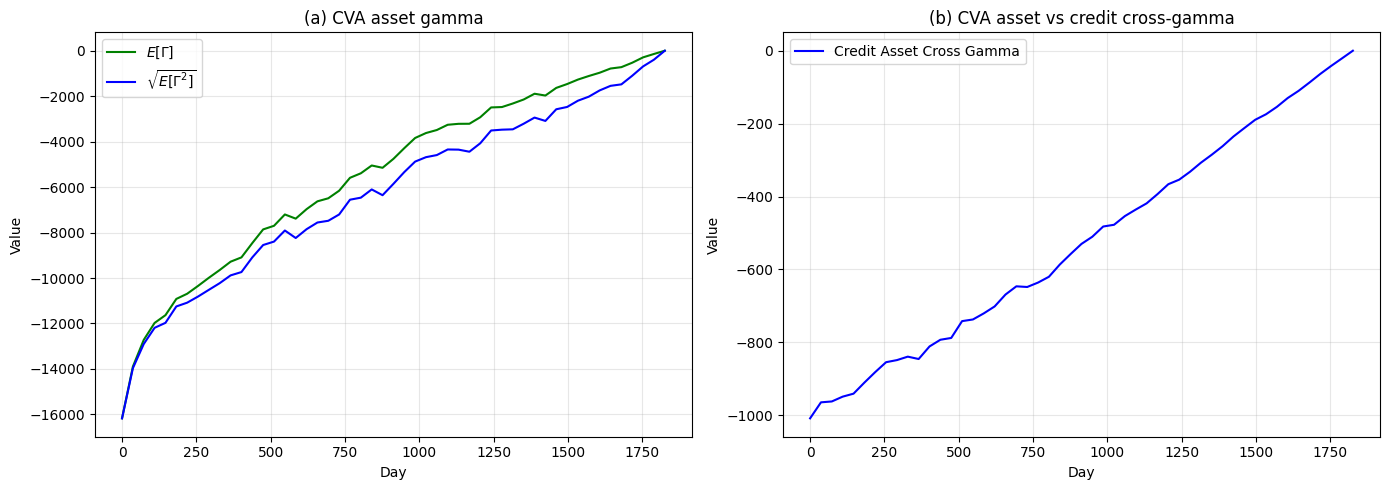

In [11]:
# Figure 1: CVA second-order risks decay profile
days = times * 365.25

# Convert gamma to "per percent" units for display
# gamma_pct = gamma_ss * S^2 * 0.01^2 = gamma_ss * S^2 * 1e-4
# But actually let's use the "dollar gamma" convention from the figure:
# gamma_figure = 0.5 * sigma^2 * S^2 * gamma_ss (this is Theta contribution)

# Figure 1a: CVA asset gamma
E_gamma = np.mean(gamma_ss_values, axis=0)
E_gamma_sq = np.mean(gamma_ss_values**2, axis=0)
sqrt_E_gamma_sq = np.sqrt(E_gamma_sq)

# Scale to match paper figure units (dollar gamma per percent^2)
# gamma_display = gamma_ss * S0^2 * (0.01)^2 = gamma_ss * 4.9e-5
scale_ss = S0**2 * 0.01**2
E_gamma_disp = E_gamma * scale_ss
sqrt_E_gamma_sq_disp = sqrt_E_gamma_sq * scale_ss

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(days, E_gamma_disp, 'g-', label=r'$E[\Gamma]$')
ax1.plot(days, -sqrt_E_gamma_sq_disp, 'b-', label=r'$\sqrt{E[\Gamma^2]}$')
ax1.set_xlabel('Day')
ax1.set_ylabel('Value')
ax1.set_title('(a) CVA asset gamma')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Figure 1b: CVA asset vs credit cross-gamma
E_cross = np.mean(cross_gamma_values * 0.0001, axis=0)  # in bp units
cross_disp = E_cross * S0 * 0.01  # scale to "per percent per bp"

ax2.plot(days, cross_disp, 'b-', label='Credit Asset Cross Gamma')
ax2.set_xlabel('Day')
ax2.set_ylabel('Value')
ax2.set_title('(b) CVA asset vs credit cross-gamma')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
path = OUT_DIR / "CVA.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()

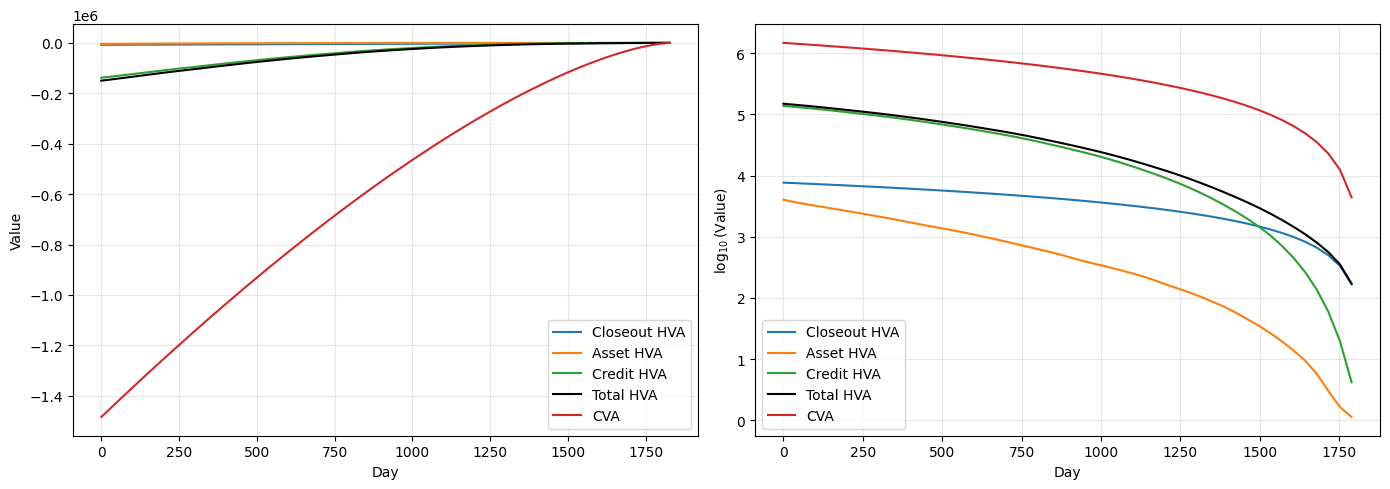

In [12]:
# Figure 2: HVA components run-down profile
# Compute cumulative HVA at each time point (integrating from t to T)

def compute_hva_profile(integrand_array, discount_factor, dt, times):
    """Compute HVA at each time t (integral from t to T)."""
    N_steps = len(times) - 1
    hva_profile = np.zeros(len(times))
    for start_idx in range(len(times)):
        if start_idx >= N_steps:
            hva_profile[start_idx] = 0.0
            continue
        # Re-discount from start_idx
        disc = np.exp(-(rF + m_X * lam) * (times[start_idx:] - times[start_idx]))
        discounted = integrand_array[:, start_idx:] * disc[np.newaxis, :]
        path_ints = np.trapezoid(discounted, dx=dt, axis=1)
        hva_profile[start_idx] = -np.mean(path_ints)
    return hva_profile

asset_profile = compute_hva_profile(asset_hva_integrand, discount_factor, dt, times)
credit_profile = compute_hva_profile(credit_hva_integrand, discount_factor, dt, times)
closeout_profile = compute_hva_profile(closeout_hva_integrand, discount_factor, dt, times)
total_profile = asset_profile + credit_profile + closeout_profile

# CVA profile
cva_profile = np.array([cva_at(S0, t) for t in times])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.plot(days, closeout_profile, label='Closeout HVA')
ax1.plot(days, asset_profile, label='Asset HVA')
ax1.plot(days, credit_profile, label='Credit HVA')
ax1.plot(days, total_profile, 'k-', label='Total HVA')
ax1.plot(days, cva_profile, label='CVA')
ax1.set_xlabel('Day')
ax1.set_ylabel('Value')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale
ax2.plot(days[:-1], np.log10(np.abs(closeout_profile[:-1]) + 1), label='Closeout HVA')
ax2.plot(days[:-1], np.log10(np.abs(asset_profile[:-1]) + 1), label='Asset HVA')
ax2.plot(days[:-1], np.log10(np.abs(credit_profile[:-1]) + 1), label='Credit HVA')
ax2.plot(days[:-1], np.log10(np.abs(total_profile[:-1]) + 1), 'k-', label='Total HVA')
ax2.plot(days[:-1], np.log10(np.abs(cva_profile[:-1]) + 1), label='CVA')
ax2.set_xlabel('Day')
ax2.set_ylabel(r'$\log_{10}$(Value)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
path = OUT_DIR / "HVA.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()

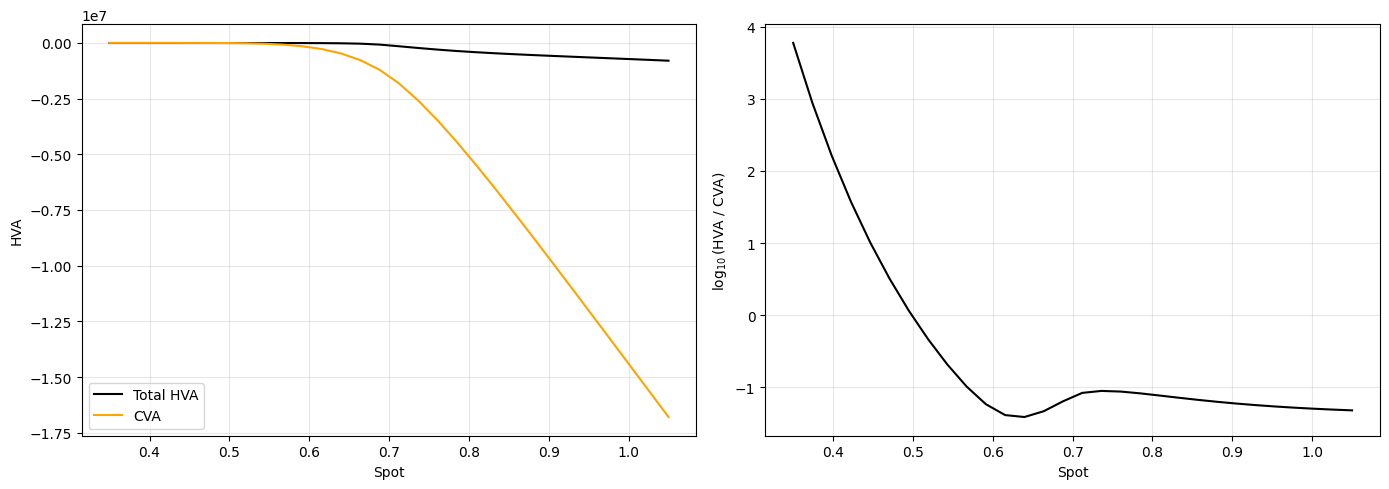

In [13]:
# Figure 3: HVA and CVA vs spot (moneyness)
spots = np.linspace(0.35, 1.05, 30)

hva_vs_spot = []
cva_vs_spot = []

for S_test in spots:
    # CVA at this spot
    c = cva_at(S_test, 0)
    cva_vs_spot.append(c)

    # HVA at this spot (deterministic approximation for speed)
    # Use formula (33) with E[...] replaced by the integrand at S = S_test
    hva_total = 0.0
    N_quad = 200
    t_grid = np.linspace(1e-4, T, N_quad)
    dt_q = t_grid[1] - t_grid[0]
    for t_i in t_grid:
        # Evolve S to t_i (use forward = S_test for zero rates)
        S_i = S_test  # Deterministic approximation

        disc = np.exp(-(rF + m_X * lam) * t_i)
        g_ss = cva_gamma_ss_analytical(S_i, t_i)
        g_sc = cva_cross_gamma_analytical(S_i, t_i) * 0.0001  # bp units
        Ds_nat = Ds_natural(S_i)
        ps = psi_s(S_i)
        pc = psi_c()

        sig2_S2 = sigma**2 * S_i**2

        asset_term = (ps / Ds_nat**2) * sig2_S2 * g_ss**2
        credit_term = (pc / Dc_bp**2) * sig2_S2 * g_sc**2
        closeout_term = lam * spread_pips * N_foreign

        hva_total += disc * (asset_term + credit_term + closeout_term) * dt_q

    hva_vs_spot.append(-hva_total)

hva_vs_spot = np.array(hva_vs_spot)
cva_vs_spot = np.array(cva_vs_spot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(spots, hva_vs_spot, 'k-', label='Total HVA')
ax1.plot(spots, cva_vs_spot, 'orange', label='CVA')
ax1.set_xlabel('Spot')
ax1.set_ylabel('HVA')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log ratio
mask = (np.abs(cva_vs_spot) > 1) & (np.abs(hva_vs_spot) > 1)
ratio = np.full_like(spots, np.nan)
ratio[mask] = np.log10(np.abs(hva_vs_spot[mask]) / np.abs(cva_vs_spot[mask]))

ax2.plot(spots[mask], ratio[mask], 'k-')
ax2.set_xlabel('Spot')
ax2.set_ylabel(r'$\log_{10}$(HVA / CVA)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
path = OUT_DIR / "Spot.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()

## 2. Application to real data

## 2.1. Data

In [14]:
start = datetime.datetime.now() - datetime.timedelta(days=3*365)
end   = datetime.datetime.now()

df_fred = web.DataReader('DCOILWTICO', 'fred', start, end)
print(df_fred.head())
df_fred.to_csv("WTI_spot_FRED.csv")

            DCOILWTICO
DATE                  
2023-04-19       79.18
2023-04-20       77.27
2023-04-21       77.86
2023-04-24       78.64
2023-04-25       77.05


In [15]:
# Load CSV from FRED
df = pd.read_csv("WTI_spot_FRED.csv", parse_dates=["DATE"], index_col="DATE")
df.rename(columns={"DCOILWTICO": "WTI_spot"}, inplace=True)

# Drop missing spot values (e.g., weekends/holidays)
df = df.dropna(subset=["WTI_spot"])

# Compute log returns and 30‑day rolling volatility (require at least 30 observations)
df["r"] = np.log(df["WTI_spot"] / df["WTI_spot"].shift(1))
df["vol30"] = df["r"].rolling(window=30, min_periods=30).std() * np.sqrt(252)
vol_ann = df["r"].std() * np.sqrt(252)
print(f"Annualized volatility: {vol_ann:.2%}")

Annualized volatility: 36.75%


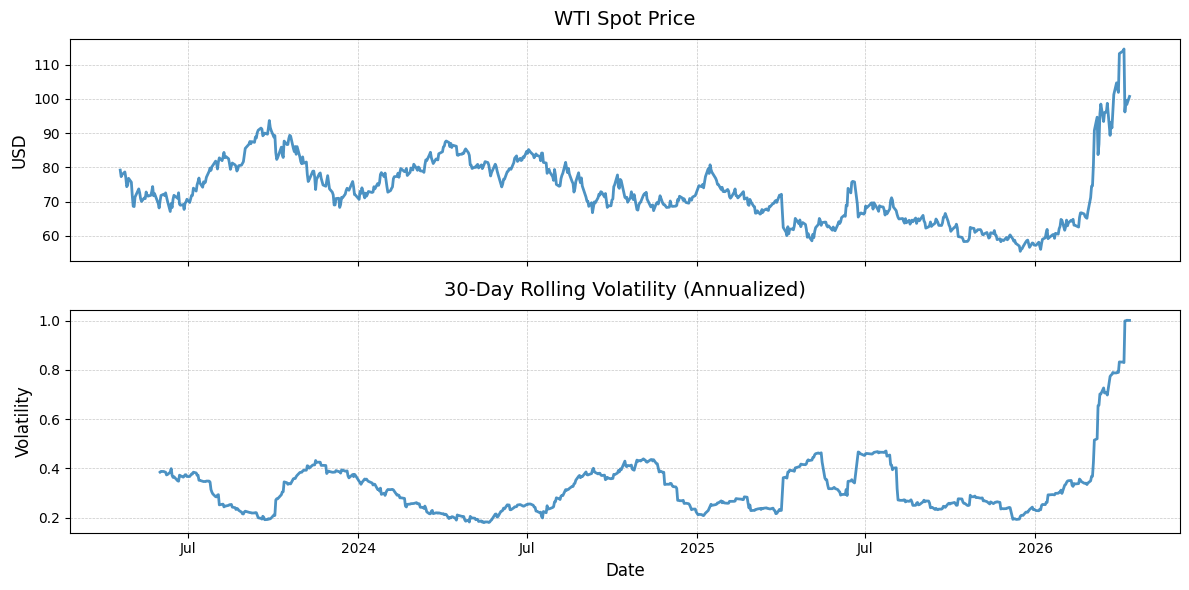

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, tight_layout=True)

# Plot the spot price
ax1.plot(df.index, df["WTI_spot"], linewidth=2, alpha=0.8)
ax1.set_title("WTI Spot Price", fontsize=14, pad=10)
ax1.set_ylabel("USD", fontsize=12)
ax1.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)

# Plot the rolling volatility
ax2.plot(df.index, df["vol30"], linewidth=2, alpha=0.8)
ax2.set_title("30‑Day Rolling Volatility (Annualized)", fontsize=14, pad=10)
ax2.set_ylabel("Volatility", fontsize=12)
ax2.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)

ax2.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=10))
ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax2.xaxis.get_major_locator()))

plt.xlabel("Date", fontsize=12)
path = OUT_DIR / "WTI.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()

### 2.2. Black-76 model

In [17]:
def black76_call(F, K, T, sigma, r):
    d1 = (np.log(F/K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return np.exp(-r*T) * (F * norm.cdf(d1) - K * norm.cdf(d2))

# ATM parameters
F0    = df["WTI_spot"].iloc[-1]
K     = F0
T     = 0.5     # 6 months
r     = 0.036   # Around the 3m US treasury bill yield
sigma = vol_ann

call_price = black76_call(F0, K, T, sigma, r)
print(f"ATM Call Price (Black‑76): {call_price:.2f} USD")

ATM Call Price (Black‑76): 10.23 USD


In [18]:
# Common styling
LINEWIDTH = 2
ALPHA     = 0.8
TITLE_FS  = 14
LABEL_FS  = 12
GRID_ARGS = dict(linestyle="--", linewidth=0.5, alpha=0.7)

In [19]:
def black76_delta(F, K, T, sigma, r):
    d1 = (np.log(F/K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return np.exp(-r*T) * norm.cdf(d1)

def black76_gamma(F, K, T, sigma, r):
    d1 = (np.log(F/K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return np.exp(-r*T) * norm.pdf(d1) / (F * sigma * np.sqrt(T))

delta = black76_delta(F0, K, T, sigma, r)
gamma = black76_gamma(F0, K, T, sigma, r)
print(f"Delta: {delta:.4f}, Gamma: {gamma:.6f}")

Delta: 0.5418, Gamma: 0.014845


### 2.3. HVA results

In [20]:
D     = 1000.0   # Hedging tolerance
psi_D = 0.01     # Unit transaction cost
f_S   = (sigma * gamma / D)**2 * psi_D
HVA_est = f_S * T * 252   # Approximation

print(f"Friction cost f_S: {f_S:.3e} USD/day")
print(f"Approximate HVA: {HVA_est:.2f} USD")

Friction cost f_S: 2.976e-13 USD/day
Approximate HVA: 0.00 USD


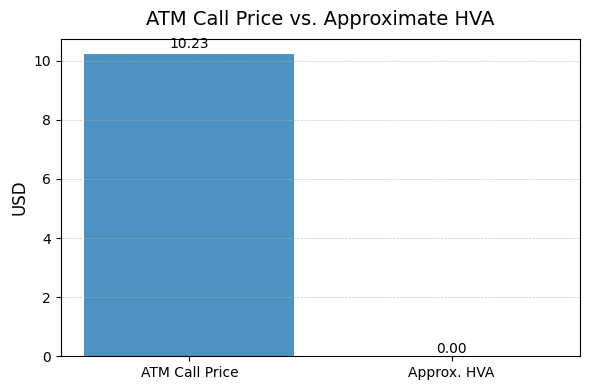

In [21]:
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
labels = ["ATM Call Price", "Approx. HVA"]
values = [call_price, HVA_est]

bars = ax.bar(labels, values, color=['tab:blue','tab:orange'], alpha=ALPHA)
ax.set_title("ATM Call Price vs. Approximate HVA", fontsize=TITLE_FS, pad=10)
ax.set_ylabel("USD", fontsize=LABEL_FS)
ax.grid(axis="y", **GRID_ARGS)

# Annotate bar values on top
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
            f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=LABEL_FS-2)
path = OUT_DIR / "Approximate HVA.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()

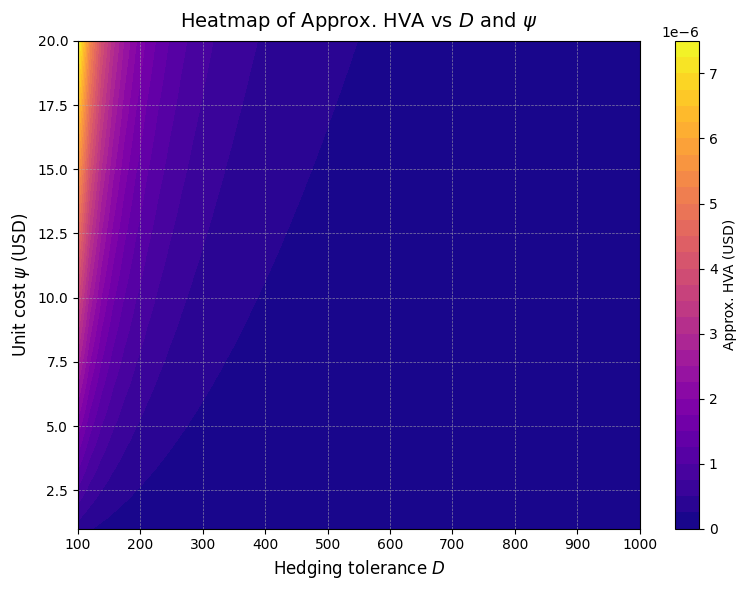

In [22]:
fig, ax = plt.subplots(figsize=(8,6), tight_layout=True)
D_vals, psi_vals = np.linspace(100,1000,50), np.linspace(1,20,50)
Dg, psig = np.meshgrid(D_vals, psi_vals, indexing='ij')
f_grid   = (sigma * gamma / Dg)**2 * psig
HVA_grid = f_grid * (T * 252)

ctr = ax.contourf(Dg, psig, HVA_grid, levels=30, cmap='plasma')
cbar = fig.colorbar(ctr, ax=ax, label='Approx. HVA (USD)')
ax.set_title('Heatmap of Approx. HVA vs $D$ and $\\psi$', fontsize=TITLE_FS, pad=10)
ax.set_xlabel('Hedging tolerance $D$', fontsize=LABEL_FS)
ax.set_ylabel('Unit cost $\\psi$ (USD)', fontsize=LABEL_FS)
ax.grid(**GRID_ARGS)
path = OUT_DIR / "Heatmap.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()

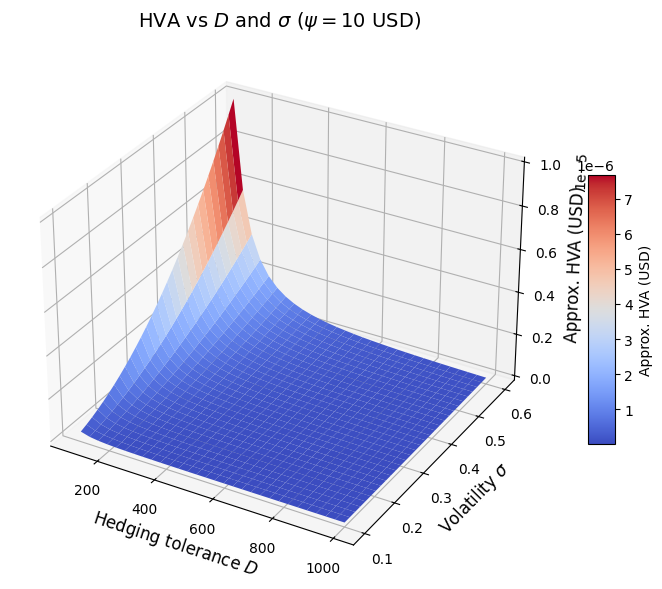

In [23]:
fig = plt.figure(figsize=(8,6), tight_layout=True)
ax3 = fig.add_subplot(111, projection='3d')

psi_fixed  = 10.0
sigma_vals = np.linspace(0.1,0.6,30)
D_vals2    = np.linspace(100,1000,30)
Sg, Dg2    = np.meshgrid(sigma_vals, D_vals2, indexing='ij')
f_grid2    = (Sg * gamma / Dg2)**2 * psi_fixed
HVA_grid2  = f_grid2 * (T * 252)

surf = ax3.plot_surface(Dg2, Sg, HVA_grid2, cmap='coolwarm', edgecolor='none')
fig.colorbar(surf, ax=ax3, shrink=0.5, aspect=10, label='Approx. HVA (USD)')

ax3.set_title('HVA vs $D$ and $\\sigma$ ($\\psi=10$ USD)', fontsize=TITLE_FS, pad=10)
ax3.set_xlabel('Hedging tolerance $D$', fontsize=LABEL_FS)
ax3.set_ylabel('Volatility $\\sigma$', fontsize=LABEL_FS)
ax3.set_zlabel('Approx. HVA (USD)', fontsize=LABEL_FS)
path = OUT_DIR / "3D.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()

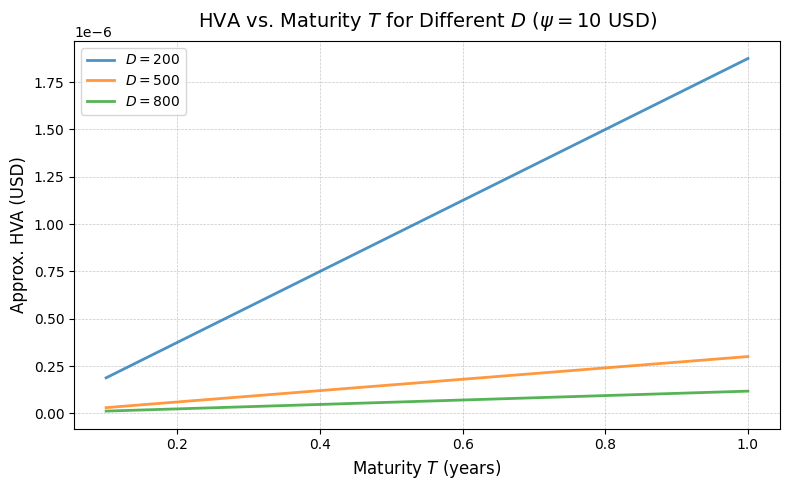

In [24]:
fig, ax = plt.subplots(figsize=(8,5), tight_layout=True)
psi_fixed = 10.0
T_vals    = np.linspace(0.1,1.0,50)
D_list    = [200, 500, 800]

for D_val in D_list:
    f_T = (sigma * gamma / D_val)**2 * psi_fixed
    H_T = f_T * (T_vals * 252)
    ax.plot(T_vals, H_T, linewidth=LINEWIDTH, alpha=ALPHA, label=f'$D={D_val}$')

ax.set_title('HVA vs. Maturity $T$ for Different $D$ ($\\psi=10$ USD)', fontsize=TITLE_FS, pad=10)
ax.set_xlabel('Maturity $T$ (years)', fontsize=LABEL_FS)
ax.set_ylabel('Approx. HVA (USD)', fontsize=LABEL_FS)
ax.legend()
ax.grid(**GRID_ARGS)
path = OUT_DIR / "D.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()

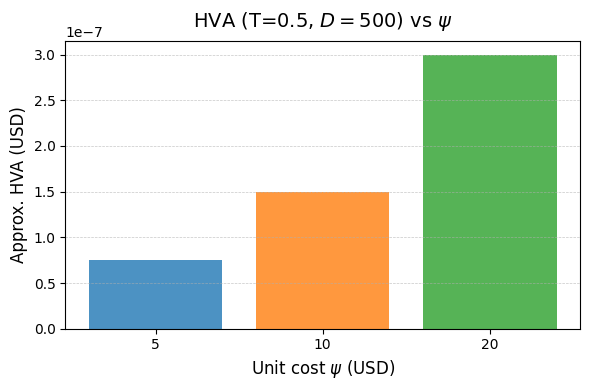

In [25]:
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
D_fixed  = 500
psi_list = [5, 10, 20]
H_vals   = [(sigma * gamma / D_fixed)**2 * psi * (T * 252) for psi in psi_list]

bars = ax.bar([str(p) for p in psi_list], H_vals, color=['C0','C1','C2'], alpha=ALPHA)
ax.set_title('HVA (T=0.5, $D=500$) vs $\\psi$', fontsize=TITLE_FS, pad=10)
ax.set_xlabel('Unit cost $\\psi$ (USD)', fontsize=LABEL_FS)
ax.set_ylabel('Approx. HVA (USD)', fontsize=LABEL_FS)
ax.grid(axis="y", **GRID_ARGS)
path = OUT_DIR / "Psi.png"
plt.savefig(path, bbox_inches="tight", dpi=150)